In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

In [16]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from matplotlib.colors import to_hex
from scipy.optimize import linear_sum_assignment

import sherlock as slk

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import matplotlib as mpl

# ── Journal figure style ────────────────────────────────────────────────
RC = {
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':             8,
    'axes.labelsize':        8,
    'axes.titlesize':        9,
    'xtick.labelsize':       7,
    'ytick.labelsize':       7,
    'legend.fontsize':       6,
    'legend.title_fontsize': 7,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.75,
    'xtick.major.width':     0.75,
    'ytick.major.width':     0.75,
    'xtick.major.size':      3,
    'ytick.major.size':      3,
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'pdf.fonttype':          42,
    'ps.fonttype':           42,
    'svg.fonttype': 'none',
}
mpl.rcParams.update(RC)

In [19]:
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS      = 5
NUM_EPOCHS  = 200
VALIDATE_EVERY = 50
BATCH_SIZE  = 4096
LATENT_DIM  = 16
PATIENCE    = 20
RESULTS_DIR = f"{paths.RESULTS_DIR}/benchmarking"
N_CLUSTERS  = 8

# Metrics tracked for scoring and box plots
METRIC_COLS = [
    'cf_ate_pearson_r',
    'cluster_f1',
    'cluster_ari',
    'cluster_ami',
    'cluster_silhouette',
    'cluster_linear_probe',
    'cluster_knn_purity',
]

# (model_key, display_name, method-specific kwargs)
# sherlock (vae) kwargs mirror the tuned hyperparameters in "demo copy.ipynb"
# (cov_lambda / H_lambda / gate_row_repulsion_lambda disabled, ce_lambda raised to 20)
METHODS = [
    ("vae",           "sherlock",      {
        "l0_lambda": 1e-1,
        "ce_lambda": 20.,
        "n_epochs_l0_warmup": 300,
    },  500),
    ("svae",          "sVAE",          {"sparse_mask_penalty": 10.0},  NUM_EPOCHS),
    ("cvae",          "cVAE",          {},  NUM_EPOCHS),
    ("contrastivevi", "contrastiveVI", {},  NUM_EPOCHS),
    ("scgen",         "scgen",         {},  NUM_EPOCHS),
]

####TODO CHECK THIS#####
METHODS = [
    ("vae",           "sherlock",      {
        "l0_lambda": 1e-1,
        "ce_lambda": 20.,
        "n_epochs_l0_warmup": 300,
    }, 500),
    ("svae",          "sVAE",          {
        "sparse_mask_penalty": 4.366473592979633,
        "beta": 0.614252574393396,
        "n_hidden": 251,
        "n_layers": 3,
        "dropout_rate": 0.28184968246925673,
        "lr": 0.00331348361550895,
    }, NUM_EPOCHS),
    ("cvae",          "cVAE",          {
        "beta": 3.2226582291306802,
        "n_hidden": 67,
        "n_layers": 1,
        "dropout_rate": 0.29147206450401036,
        "lr": 0.006205861500406846,
    }, NUM_EPOCHS),
    ("contrastivevi", "contrastiveVI", {
        "wasserstein_penalty": 4.399492045282824,
        "n_hidden": 94,
        "n_layers": 2,
        "dropout_rate": 0.2902495045654139,
        "lr": 0.0005218479707033748,
    }, NUM_EPOCHS),
    ("scgen",         "scgen",         {}, NUM_EPOCHS),
]

os.makedirs(f"{RESULTS_DIR}/models",   exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/figures",  exist_ok=True)

print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/benchmarking


## Data loading and ground-truth ATE

In [20]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|██████████| 681/681 [00:10<00:00, 66.97it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for clustering evaluation

In [21]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Benchmark loop

Each method is trained `N_RUNS` times independently. The best-scoring run
per method is saved to `results/models/`. Metrics are computed after training
using the proper counterfactual ATE protocol; the clustering cut is chosen
automatically via the elbow method.

In [22]:
records         = []
best_run_out    = {}   # method → out dict of best single run
best_run_model  = {}   # method → model of best single run
best_run_score  = {}   # method → avg metric score of best single run
best_run_path   = {}   # method → run_x.pth of best single run

for model_key, display_name, extra_kwargs, EPOCHS, in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    # Each method gets its own folder; individual runs are checkpointed there
    # so a re-executed notebook reloads finished runs instead of retraining.
    model_dir = f"{RESULTS_DIR}/models/{display_name}"
    os.makedirs(model_dir, exist_ok=True)

    for run in range(N_RUNS):
        print(f"\n  -- {display_name} run {run + 1}/{N_RUNS} --")

        run_path = f"{model_dir}/run_{run}.pth"

        if os.path.exists(run_path):
            print(f"    Found checkpoint → {run_path}, loading instead of retraining")
            model = slk.tl.load_results(run_path).to(DEVICE)
            out = {"model": model, "param_store": None}
        else:
            out = slk.tl.run(
                data,
                model=model_key,
                batch_size=BATCH_SIZE,
                num_epochs=EPOCHS,
                device=DEVICE,
                latent_dim=LATENT_DIM,
                patience=PATIENCE,
                validate_every=VALIDATE_EVERY,
                seed=run,
                **extra_kwargs,
            )
            model = out['model']
            slk.tl.save_results(out, run_path)
            print(f"    Saved → {run_path}")

        metrics = slk.tl.evaluate_model(
            model,
            data,
            treat_effect_adata,
            pathway_df_indexed,
            all_genes_filtered,
            n_clusters=N_CLUSTERS,
            device=DEVICE,
            use_rho=False,
        )

        # Track best run for this method
        run_avg = float(metrics['cf_ate_pearson_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out
            best_run_model[display_name] = model
            best_run_path[display_name]  = run_path

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                val_str = f"{v:.4f}" if np.isfinite(float(v)) else "NaN"
                print(f"    {k:30s} = {val_str}")

    # Save best run model as an exact copy of its own run_x.pth. Copying (vs.
    # re-saving from memory) guarantees best.pth carries the best run's
    # state_dict AND its Pyro param store (sigma_fac, …). The store is not in
    # state_dict, and the *global* Pyro store reflects whichever run ran last,
    # not necessarily the best — so we never rely on it.
    import shutil
    save_path = f"{model_dir}/best.pth"
    shutil.copyfile(best_run_path[display_name], save_path)
    print(f"\n  Saved best {display_name} model → {save_path} "
          f"(copied from {os.path.basename(best_run_path[display_name])})")

results_df = pd.DataFrame(records)
print("\nDone.")


sherlock  (5 runs)

  -- sherlock run 1/5 --
    Found checkpoint → results/benchmarking/models/sherlock/run_0.pth, loading instead of retraining
    cf_ate_pearson_r               = 0.7471
    cluster_accuracy               = 0.9910
    cluster_precision              = 0.9902
    cluster_recall                 = 0.9901
    cluster_f1                     = 0.9900
    cluster_ari                    = 0.9813
    cluster_ami                    = 0.9773
    cluster_homogeneity            = 0.9783
    cluster_completeness           = 0.9781
    cluster_v_measure              = 0.9782
    cluster_silhouette             = 0.4323
    cluster_purity                 = 0.9910
    cluster_knn_purity             = 0.9845
    cluster_linear_probe           = 0.9910
    rho_z_pearson_r                = 0.7857

  -- sherlock run 2/5 --
    Found checkpoint → results/benchmarking/models/sherlock/run_1.pth, loading instead of retraining
    cf_ate_pearson_r               = 0.7505
    cluster_accuracy  

## Results summary

In [23]:
summary = (
    results_df
    .groupby('method')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
# Preserve METHODS order
method_order = [m[1] for m in METHODS]
summary = summary.reindex([m for m in method_order if m in summary.index])
print(summary.to_string())

              cf_ate_pearson_r         cluster_f1         cluster_ari         cluster_ami         cluster_silhouette         cluster_linear_probe         cluster_knn_purity        
                          mean     std       mean     std        mean     std        mean     std               mean     std                 mean     std               mean     std
method                                                                                                                                                                              
sherlock                0.7447  0.0064     0.9825  0.0279      0.9842  0.0173      0.9809  0.0188             0.4266  0.0070               0.9893  0.0016             0.9842  0.0016
sVAE                    0.4097  0.0099     0.7600  0.1264      0.6815  0.1652      0.7650  0.1394             0.2450  0.0384               0.9881  0.0047             0.9151  0.0295
cVAE                    0.5188  0.0084     0.8357  0.0853      0.8572  0.0933      0.9134  0.04

## Box plots

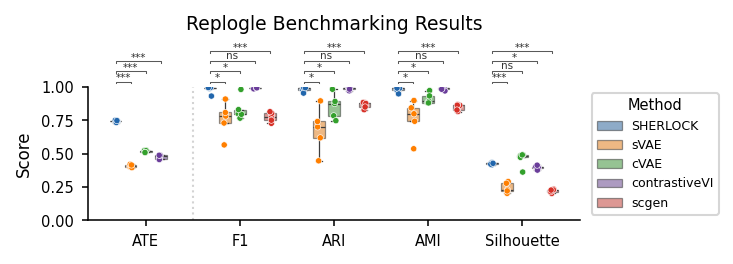

In [24]:
# Toggle significance brackets (SHERLOCK vs each baseline, per metric column).
# Welch's t-test on the per-run values, Benjamini-Hochberg FDR across the whole
# family, drawn ggsignif-style as ns / * / ** / *** (same as norman_figure Panel A).
SIG = True

CLR_SHERLOCK    = '#2166ac'
CLR_GEARS       = '#d73027'

METHOD_PALETTE = {
    'SHERLOCK':      CLR_SHERLOCK,
    'cVAE':          '#33a02c',
    'sVAE':          '#ff7f00',
    'contrastiveVI': '#6a3d9a',
    'GEARS':         CLR_GEARS,
}

label_map = {
    'cf_ate_pearson_r':   'ATE',
    'cluster_f1':         'F1',
    'cluster_ari':        'ARI',
    'cluster_ami':        'AMI',
    'cluster_silhouette': 'Silhouette',
    # 'cluster_linear_probe': 'Linear\nProbe',
    # 'cluster_knn_purity': 'kNN\nPurity',
}

METRIC_COLS_PLOT = [
    m for m in METRIC_COLS
    if m not in ['cluster_linear_probe', 'cluster_knn_purity']
]

# Display names matched to METHOD_PALETTE keys (sherlock -> SHERLOCK)
method_display = {
    'sherlock':      'SHERLOCK',
}
method_order = [method_display.get(m[1], m[1]) for m in METHODS]

df_melted = results_df.melt(
    id_vars='method', value_vars=METRIC_COLS_PLOT, var_name='metric', value_name='value'
)
df_melted['method'] = df_melted['method'].map(lambda m: method_display.get(m, m))
df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS_PLOT],
    ordered=True,
)
df_melted['method'] = pd.Categorical(
    df_melted['method'], categories=method_order, ordered=True
)
df_melted['value'] = df_melted['value'].clip(lower=0)

# scgen has no ATE result to show
df_melted = df_melted[~((df_melted['method'] == 'scgen') & (df_melted['metric'] == 'cf_ate_pearson_r'))]

# Fall back to gray for any method not in METHOD_PALETTE (scgen is colored red)
palette = {m: METHOD_PALETTE.get(m, '#999999') for m in method_order}
palette['scgen'] = CLR_GEARS

# Taller when SIG is on so the stacked brackets have headroom above the boxes.
fig, ax = plt.subplots(figsize=(6.5*0.75, (2.7 if SIG else 2)*0.75))

# NOTE: stripplot's dodge always spans a fixed width of 0.8 (it has no `width`
# kwarg), so the boxplot must also dodge over width=0.8 for box/point centers
# to line up -- otherwise outer hue levels (e.g. scgen) drift off to the side.
# `gap` shrinks the box's visual thickness without moving its dodge position.
sns.boxplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    hue_order=method_order,
    palette=palette,
    width=0.8,
    gap=0.25,
    linewidth=0.6,
    showfliers=False,
    boxprops=dict(alpha=0.55),
    ax=ax,
)

sns.stripplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    hue_order=method_order,
    palette=palette,
    dodge=True,
    jitter=0.1,
    size=3,
    linewidth=0.3,
    edgecolor='white',
    legend=False,
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('Score')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 1.0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Separator between ATE and clustering metrics
ax.axvline(0.5, color='lightgray', linewidth=1.0, linestyle=':')

# ── Significance: SHERLOCK vs every other method, per metric column ────────
# Brackets are drawn above the y=1.0 axis (clip_on=False) so the score axis
# stays a clean 0-1; savefig uses bbox_inches='tight' so they aren't clipped.
if SIG:
    from scipy import stats as _stats
    _sig_metrics = METRIC_COLS_PLOT                        # raw metric names, in column order
    _sig_others  = [m for m in method_order if m != 'SHERLOCK']

    def _mvals(_mk, _meth):
        return df_melted[(df_melted['metric'] == _mk) &
                         (df_melted['method'] == _meth)]['value'].dropna().to_numpy()

    _comps = []                                            # [col_i, other_method, p]
    for _i, _mk in enumerate(_sig_metrics):
        _s = _mvals(_mk, 'SHERLOCK')
        for _o in _sig_others:
            _ov = _mvals(_mk, _o)
            if len(_s) < 2 or len(_ov) < 2:
                continue
            _comps.append([_i, _o, _stats.ttest_ind(_s, _ov, equal_var=False).pvalue])

    # Benjamini-Hochberg across the whole family
    _pv = np.array([c[2] for c in _comps])
    _ord = np.argsort(_pv); _mtot = len(_pv); _adj = np.empty(_mtot); _prev = 1.0
    for _k in range(_mtot - 1, -1, -1):
        _ix = _ord[_k]; _prev = min(_prev, _pv[_ix] * _mtot / (_k + 1)); _adj[_ix] = min(_prev, 1.0)
    for _c, _pa in zip(_comps, _adj):
        _c.append(_pa)

    def _stars(_p):
        return '***' if _p < 1e-3 else '**' if _p < 1e-2 else '*' if _p < 0.05 else 'ns'

    # dodge geometry (boxplot width=0.8, one box per method)
    _n_hue, _box_w = len(method_order), 0.8
    def _xpos(_i, _meth):
        _j = method_order.index(_meth)
        return _i - _box_w / 2 + _box_w / (2 * _n_hue) + _j * (_box_w / _n_hue)

    _y0   = 1.03                                           # first bracket just above the y=1.0 axis
    _step = 0.075                                          # gap between stacked brackets
    _tick = 0.012                                          # bracket end-tick height
    _lbl_h = 0.028                                         # ink height reserved for a star label
    # Asterisk glyphs sit high in the text box; 'ns' letters sit on the baseline.
    # These per-label nudges land the ink at the same height above every bracket
    # line so all labels read as equal-height regardless of glyph.
    _lbl_dy = {'ns': 0.006}
    _ytop = _y0
    for _i in range(len(_sig_metrics)):
        _col = sorted([c for c in _comps if c[0] == _i],
                      key=lambda c: method_order.index(c[1]))   # nearest method lowest
        for _lvl, (_, _o, _p, _pa) in enumerate(_col):
            _x1, _x2 = _xpos(_i, 'SHERLOCK'), _xpos(_i, _o)
            _y = _y0 + _lvl * _step
            ax.plot([_x1, _x1, _x2, _x2], [_y, _y + _tick, _y + _tick, _y],
                    lw=0.5, c='0.35', clip_on=False)
            _lbl = _stars(_pa)
            ax.text((_x1 + _x2) / 2, _y + _tick + _lbl_dy.get(_lbl, -0.014), _lbl,
                    ha='center', va='bottom', fontsize=5, color='0.2', clip_on=False)
            _ytop = max(_ytop, _y + _tick + _lbl_h)

    # Title above the tallest bracket (axis is 0-1, so a data value == axes frac).
    ax.set_title('Replogle Benchmarking Results', y=_ytop + 0.04)
else:
    ax.set_title('Replogle Benchmarking Results', pad=6)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.svg', bbox_inches='tight')
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.pdf', bbox_inches='tight')
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.png', bbox_inches='tight')
plt.show()

## SHERLOCK robustness / reproducibility

Reproducibility of SHERLOCK across the `N_RUNS` independently-seeded runs, in the
same style as `norman_figure.ipynb` Panel B. Three metrics:

- **ρ_corr cross-run r** — leave-one-out Spearman correlation of the learned
  perturbation-covariance matrix against the mean of the other runs.
- **W coact. cross-run r** — same, on the permutation-invariant gate
  co-activation matrix.
- **CF effect size corr.** — per-run Pearson r between predicted and observed
  counterfactual effect magnitudes.

Loaded cached robustness matrices for 5 runs.
effect_size_r: mean = 0.8914  95% CI [0.8831, 0.8997]  (n=5)
rho_corr_r: mean = 0.7628  95% CI [0.7488, 0.7828]  (n=5)
w_coact_r: mean = 0.4379  95% CI [0.3893, 0.4864]  (n=5)


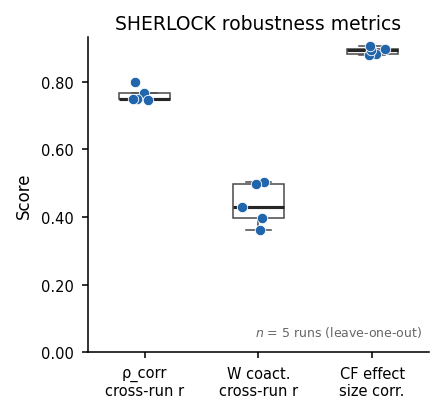

SHERLOCK robustness figure saved.


In [25]:
# ── SHERLOCK robustness / reproducibility across N runs ───────────────────
# Same three metrics (and same style) as norman_figure.ipynb Panel B, computed
# on the cached SHERLOCK benchmark runs:
#   * rho_corr    cross-run r : leave-one-out Spearman r of the learned
#                               perturbation-covariance matrix vs. the mean of
#                               the other runs' matrices.
#   * W coact.    cross-run r : same, on the (P, P) cosine-normalized gate
#                               co-activation matrix (permutation-invariant to
#                               the K gate dims, so comparable across runs).
#   * CF effect   size corr.  : per-run Pearson r between predicted and observed
#                               counterfactual effect magnitudes (|ATE| norms).
from scipy.stats import pearsonr, spearmanr, bootstrap

SHERLOCK_DIR = f"{RESULTS_DIR}/models/sherlock"


def _effect_size_r(pred_df, obs_df):
    common = pred_df.index.intersection(obs_df.index)
    if len(common) < 3:
        return float('nan')
    p_norms = pred_df.loc[common].apply(np.linalg.norm, axis=1).values
    o_norms = obs_df.loc[common].apply(np.linalg.norm, axis=1).values
    v = np.isfinite(p_norms) & np.isfinite(o_norms)
    return float(pearsonr(p_norms[v], o_norms[v])[0]) if v.sum() > 2 else float('nan')


def _w_coact_matrix(W, threshold=0.5):
    """(P, P) cosine-normalized perturbation co-activation matrix. Invariant to
    permutation of the K gate dimensions, so it can be compared directly across
    independently trained runs (unlike the raw W)."""
    W_bin = (W > threshold).astype(float)
    dot   = W_bin @ W_bin.T
    norms = np.sqrt(np.diag(dot))
    return dot / (np.outer(norms, norms) + 1e-8)


def _flat_triu(M):
    return M[np.triu_indices(M.shape[0], k=1)]


def _loo_spearman_df(mats_by_run, metric_name):
    """Spearman r between each run's (P, P) matrix and the elementwise mean of
    every OTHER run's matrix (leave-one-out) — one row per run. These n points
    each depend on a distinct held-out run, so they behave like an i.i.d.
    sample (unlike the n(n-1)/2 non-independent all-pairs comparisons)."""
    rows = []
    keys = sorted(mats_by_run)
    for k in keys:
        others = [mats_by_run[j] for j in keys if j != k]
        if not others:
            continue
        mean_other = np.mean(others, axis=0)
        vi, vj = _flat_triu(mats_by_run[k]), _flat_triu(mean_other)
        valid  = np.isfinite(vi) & np.isfinite(vj)
        r = float(spearmanr(vi[valid], vj[valid])[0]) if valid.sum() > 2 else float('nan')
        rows.append({'metric': metric_name, 'run': k, 'r': r})
    return pd.DataFrame(rows)


# ── Compute (cached) per-run matrices + effect-size correlations ──────────
ROBUST_MATS_PATH = f"{RESULTS_DIR}/sherlock_robustness_matrices.npz"
ROBUST_EFF_PATH  = f"{RESULTS_DIR}/sherlock_robustness_effect.csv"
run_ckpts = {run: f"{SHERLOCK_DIR}/run_{run}.pth" for run in range(N_RUNS)
             if os.path.exists(f"{SHERLOCK_DIR}/run_{run}.pth")}


def _cache_fresh(cache_path, source_paths):
    """True if cache exists and is newer than every source checkpoint, so a
    retrained run automatically invalidates the cached matrices."""
    if not os.path.exists(cache_path):
        return False
    cm = os.path.getmtime(cache_path)
    return all(os.path.exists(s) and os.path.getmtime(s) <= cm for s in source_paths)


_fresh = _cache_fresh(ROBUST_MATS_PATH, run_ckpts.values()) and \
         _cache_fresh(ROBUST_EFF_PATH, run_ckpts.values())

if _fresh:
    _saved       = np.load(ROBUST_MATS_PATH)
    rho_by_run   = {int(k.split('_')[-1]): _saved[k] for k in _saved.files if k.startswith('rho_corr_')}
    wcoact_by_run = {int(k.split('_')[-1]): _saved[k] for k in _saved.files if k.startswith('wcoact_')}
    eff_df       = pd.read_csv(ROBUST_EFF_PATH)
    print(f"Loaded cached robustness matrices for {len(rho_by_run)} runs.")
else:
    rho_by_run, wcoact_by_run, eff_records = {}, {}, []
    for run, ckpt in run_ckpts.items():
        print(f"  run {run}: eval + counterfactual effects...")
        model = slk.tl.load_results(ckpt).to(DEVICE)
        slk.tl.eval_single(model, data, obsm_key='_z_robust', uns_key='_robust', device=DEVICE)
        tmp = data.uns['_robust']
        if tmp.get('rho_corr') is not None:
            rho_by_run[run] = np.asarray(tmp['rho_corr'], dtype=float)
        if tmp.get('W') is not None:
            wcoact_by_run[run] = _w_coact_matrix(np.asarray(tmp['W'], dtype=float))
        ate  = model.predict_counterfactual_effects(
            data, n_centroids=25, observed_effect=data.uns['treat_effect'], approximate=False,
        )
        eff_records.append({'run': run, 'effect_size_r': _effect_size_r(ate['predicted_df'], ate['observed_df'])})
    eff_df = pd.DataFrame(eff_records)
    np.savez(
        ROBUST_MATS_PATH,
        **{f'rho_corr_{k}': v for k, v in rho_by_run.items()},
        **{f'wcoact_{k}':   v for k, v in wcoact_by_run.items()},
    )
    eff_df.to_csv(ROBUST_EFF_PATH, index=False)
    print(f"Computed and cached robustness matrices for {len(rho_by_run)} runs.")

# ── Per-run counterfactual effect matrices (cached) ───────────────────────
# Needed for TWO different columns of the robustness figure:
#   * cross-run reproducibility of the predicted effect profiles
#   * accuracy of the predicted effect sizes against the measured effects
CF_PATH = f"{RESULTS_DIR}/sherlock_cf_effects.npz"
if os.path.exists(CF_PATH):
    _cf = np.load(CF_PATH, allow_pickle=True)
else:
    _store = {}
    _obs = None
    for run, ckpt in run_ckpts.items():
        _m = slk.tl.load_results(ckpt).to(DEVICE)
        _ate = _m.predict_counterfactual_effects(
            data, n_centroids=25, observed_effect=data.uns['treat_effect'], approximate=False,
        )
        _p, _o = _ate['predicted_df'], _ate['observed_df']
        _common = _p.index.intersection(_o.index)
        _store[f'pred_{run}'] = _p.loc[_common].values.astype(np.float32)
        if _obs is None:
            _obs = _o.loc[_common].values.astype(np.float32)
            _store['perts'] = np.array(_common, dtype=object)
        del _m
    _store['obs'] = _obs
    np.savez_compressed(CF_PATH, **_store)
    _cf = np.load(CF_PATH, allow_pickle=True)

pred_by_run = {int(k.split('_')[-1]): _cf[k] for k in _cf.files if k.startswith('pred_')}
obs_mat     = _cf['obs']


def _loo_spearman_flat(mats_by_run, metric_name):
    """Leave-one-out Spearman for non-symmetric (perturbation x gene) matrices:
    each run against the elementwise mean of the other runs."""
    rows, keys = [], sorted(mats_by_run)
    for k in keys:
        mean_other = np.mean([mats_by_run[j] for j in keys if j != k], axis=0)
        a, b = mats_by_run[k].ravel(), mean_other.ravel()
        v = np.isfinite(a) & np.isfinite(b)
        rows.append({'metric': metric_name, 'run': k, 'r': float(spearmanr(a[v], b[v])[0])})
    return pd.DataFrame(rows)


# ── Assemble the long-form robustness table ───────────────────────────────
# Three cross-run reproducibility measures + one accuracy measure against data.
L_RHO = 'Perturbation\ncorrelation'
L_GATE = 'Gate\nco-activation'
L_CFP = 'Counterfactual\neffect profile'
L_CFS = 'Counterfactual\neffect size'
ROBUST_LABELS = {'rho_corr_r': L_RHO, 'w_coact_r': L_GATE,
                 'cf_effect_r': L_CFP, 'effect_size_r': L_CFS}

pairwise_df = pd.concat([
    _loo_spearman_df(rho_by_run, 'rho_corr_r'),
    _loo_spearman_df(wcoact_by_run, 'w_coact_r'),
    _loo_spearman_flat(pred_by_run, 'cf_effect_r'),
], ignore_index=True)

df_robust = pd.concat([
    pairwise_df.rename(columns={'r': 'Score'})[['metric', 'Score']],
    eff_df[['effect_size_r']].rename(columns={'effect_size_r': 'Score'}).assign(metric='effect_size_r'),
], ignore_index=True)
df_robust['Metric'] = pd.Categorical(
    df_robust['metric'].map(ROBUST_LABELS),
    categories=[ROBUST_LABELS[k] for k in ROBUST_LABELS], ordered=True,
)

print(df_robust.groupby('metric', observed=True)['Score'].agg(['mean', 'std']).round(3).to_string())

# ── Plot: reproducibility columns (blue) vs accuracy column (grey) ────────
CLR_ACC = '#7f7f7f'
_pal = {L_RHO: CLR_SHERLOCK, L_GATE: CLR_SHERLOCK, L_CFP: CLR_SHERLOCK, L_CFS: CLR_ACC}

fig_r, ax_r = plt.subplots(figsize=(4.4, 3.0))
sns.stripplot(data=df_robust, x='Metric', y='Score', hue='Metric', palette=_pal, legend=False,
              size=5, jitter=0.15, linewidth=0.4, edgecolor='white', ax=ax_r)
sns.boxplot(data=df_robust, x='Metric', y='Score', color='white', width=0.45, linewidth=0.75,
            fliersize=0, ax=ax_r, boxprops=dict(edgecolor='0.3'),
            whiskerprops=dict(color='0.3'), capprops=dict(color='0.3'),
            medianprops=dict(color='0.15', linewidth=1.5))
ax_r.set_ylim(0, 1.18)
ax_r.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax_r.set_xlabel('')
ax_r.set_ylabel('Correlation')
ax_r.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_r.axvline(2.5, color='0.75', lw=0.6, ls='--')
ax_r.plot([-0.4, 2.4], [1.12, 1.12], color=CLR_SHERLOCK, lw=1, clip_on=False)
ax_r.text(1.0, 1.14, 'reproducibility across runs', ha='center', va='bottom',
          fontsize=7, color=CLR_SHERLOCK)
ax_r.plot([2.6, 3.4], [1.12, 1.12], color=CLR_ACC, lw=1, clip_on=False)
ax_r.text(3.0, 1.14, 'accuracy vs data', ha='center', va='bottom', fontsize=7, color=CLR_ACC)
ax_r.text(0.99, 0.02, f'$n$ = {len(run_ckpts)} runs', transform=ax_r.transAxes,
          ha='right', va='bottom', fontsize=6, color='0.4')
plt.tight_layout()
for _ext in ('png', 'svg', 'pdf'):
    fig_r.savefig(f"{RESULTS_DIR}/figures/sherlock_robustness.{_ext}",
                  dpi=300 if _ext == 'png' else None, bbox_inches='tight')
plt.show()
print('SHERLOCK robustness figure saved.')


## Per-method best models — latent space UMAPs

For each method, re-eval the best run, compute UMAP on non-NTC cells, cluster the
pathway-gene subset of z_corr (maxclust), align predicted clusters to true pathways
via Hungarian matching, and save the figure.


Generating figure for best sherlock model


/var/tmp/ipykernel_3021632/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sherlock_best_umap.svg


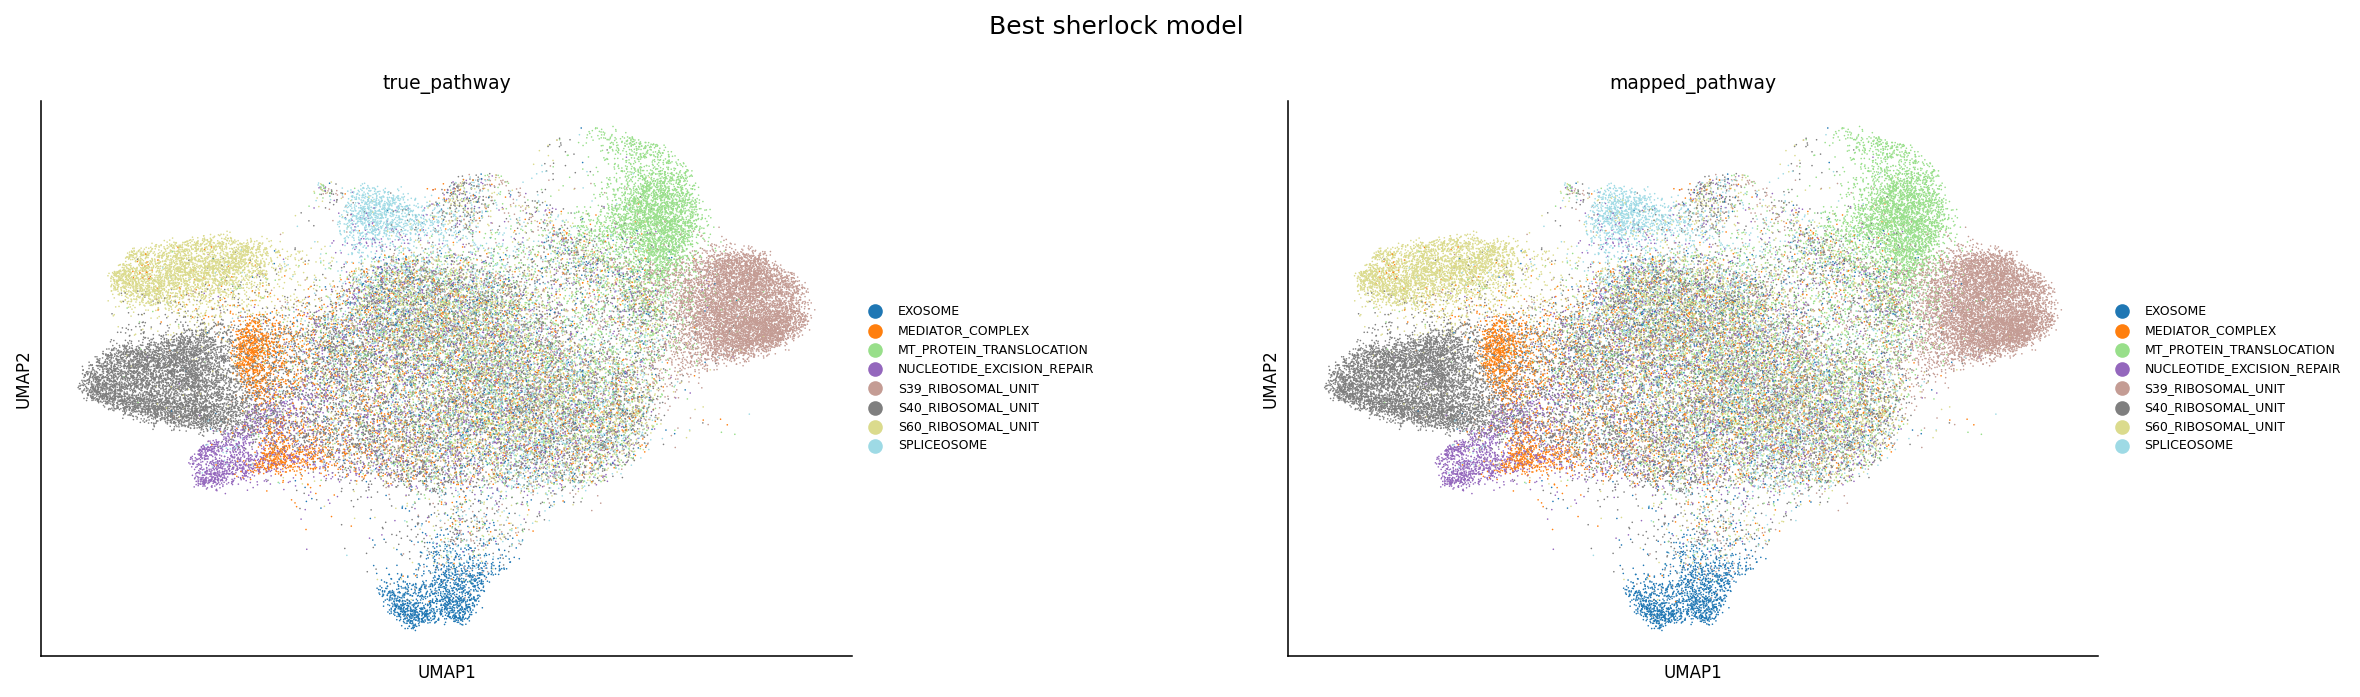


Generating figure for best sVAE model


/var/tmp/ipykernel_3021632/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sVAE_best_umap.svg


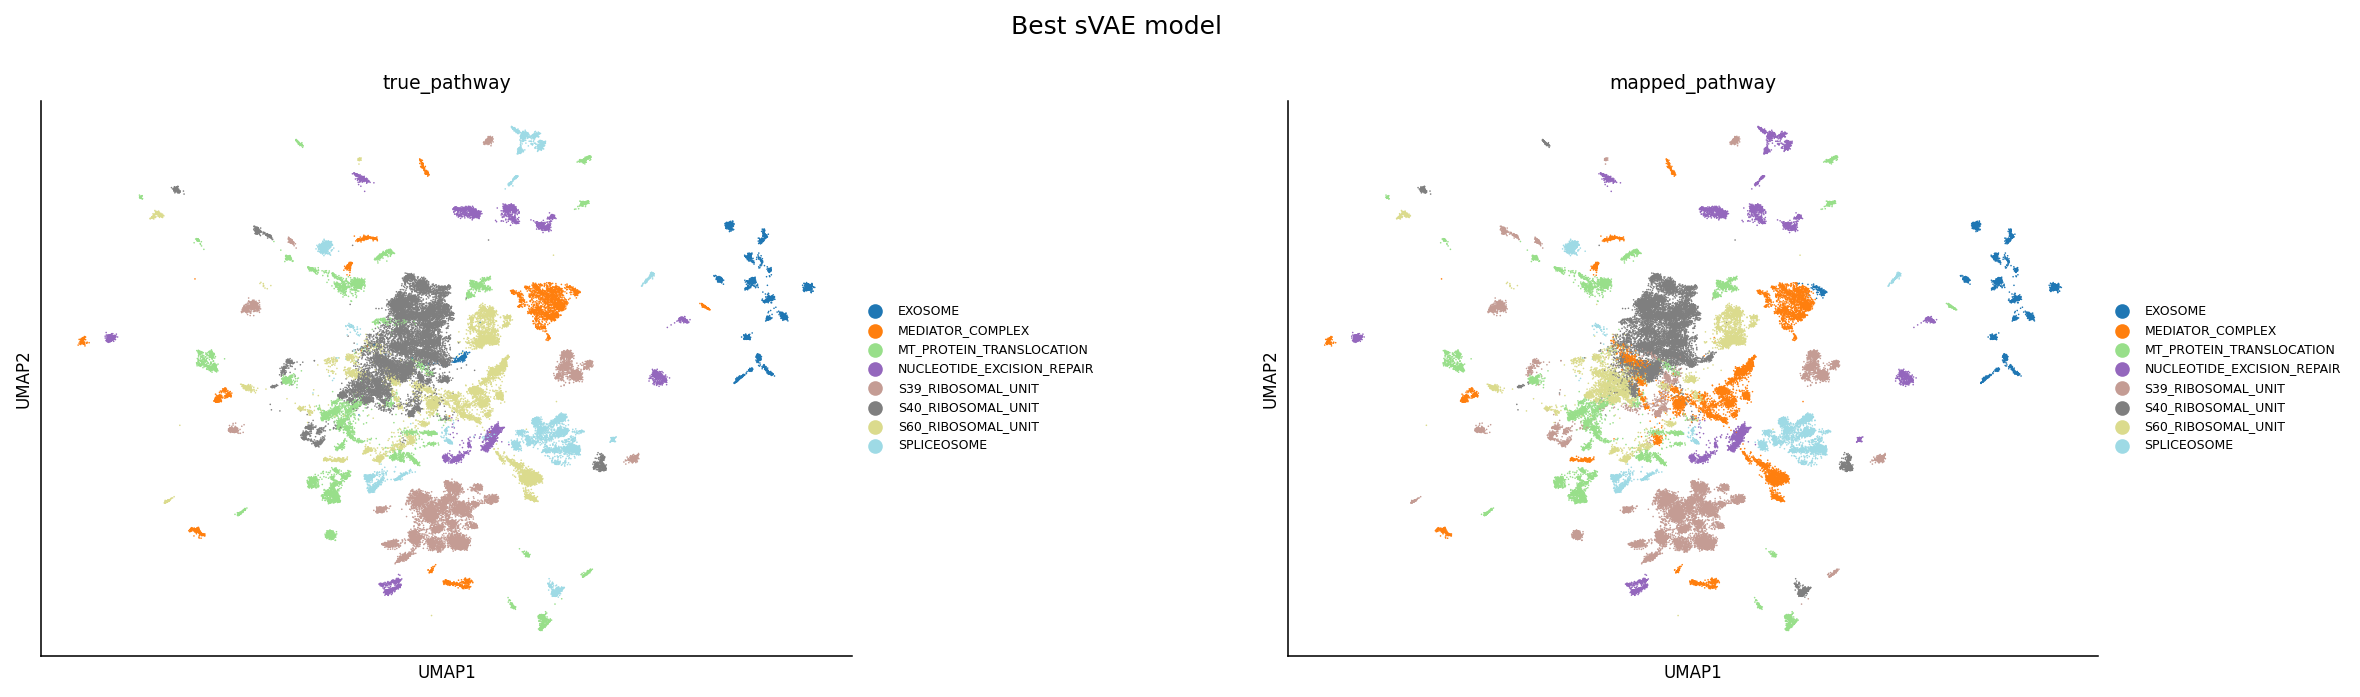


Generating figure for best cVAE model


/opt/conda/envs/perturb/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited at iteration 2000 with accuracies 
[7.37443077e-15 5.72399601e-08 1.13338572e-07 1.41887554e-06]
not reaching the requested tolerance 6.556510925292969e-07.
Use iteration 1906 instead with accuracy 
2.4970235984850186e-07.

  _, diffusion_map = lobpcg(
/opt/conda/envs/perturb/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited postprocessing with accuracies 
[6.55557877e-15 5.88292569e-08 9.66906895e-08 8.43291508e-07]
not reaching the requested tolerance 6.556510925292969e-07.
  _, diffusion_map = lobpcg(
/var/tmp/ipykernel_3021632/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/cVAE_best_umap.svg


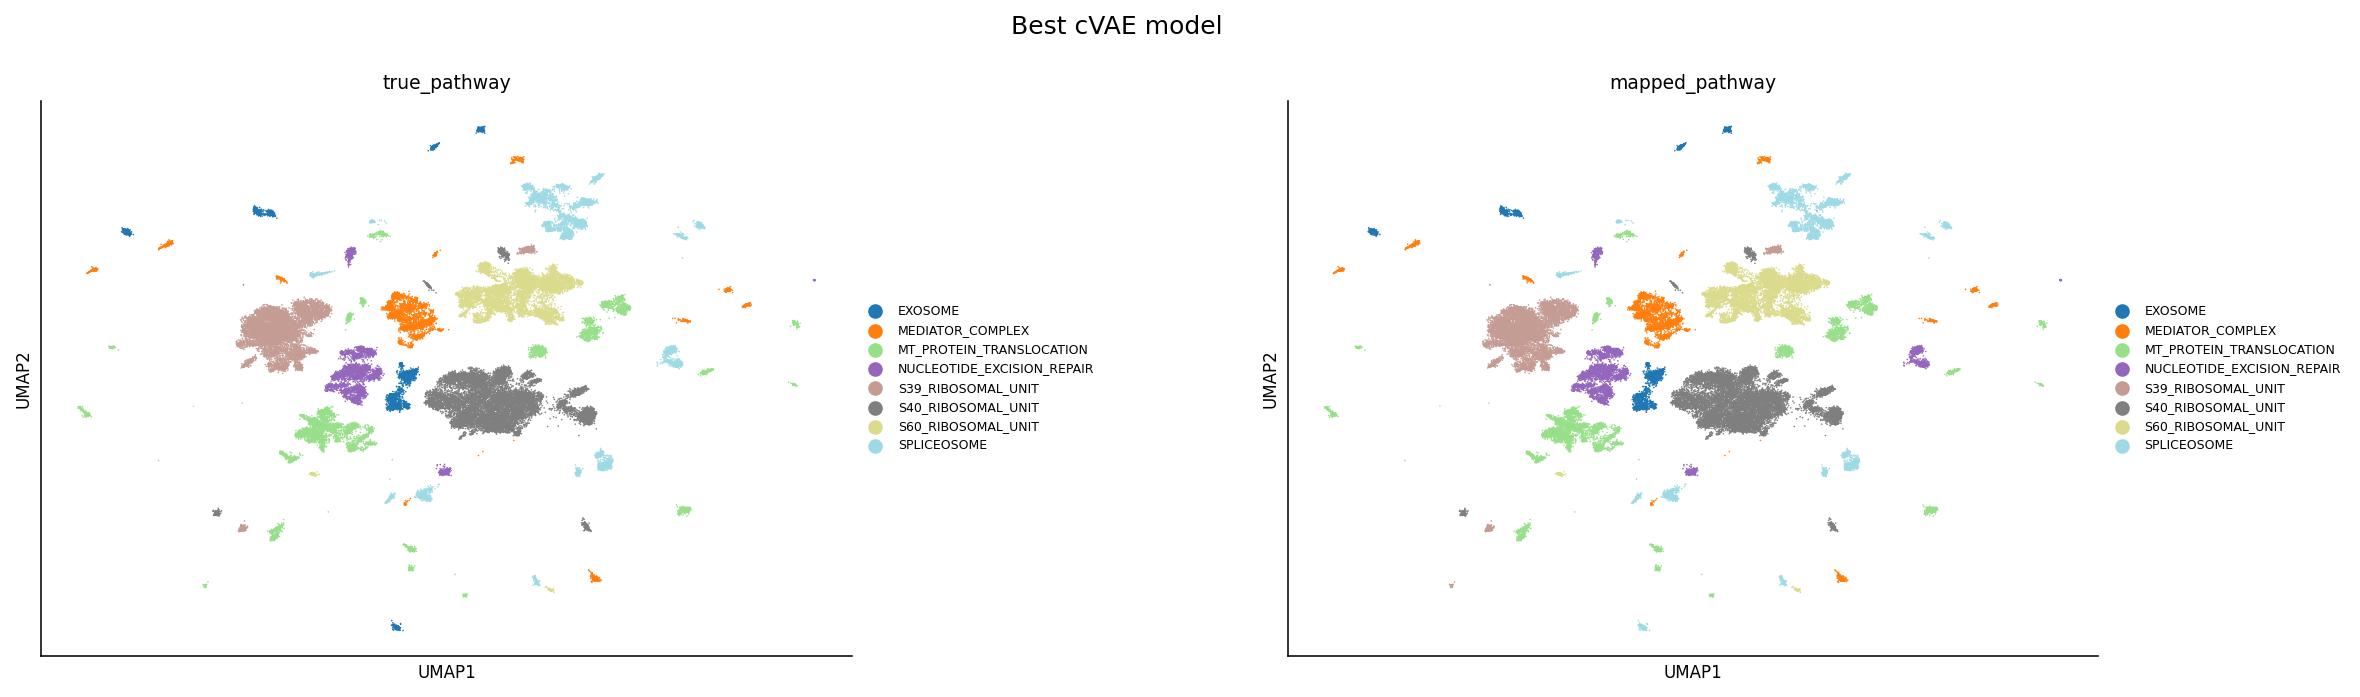


Generating figure for best contrastiveVI model


/var/tmp/ipykernel_3021632/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/contrastiveVI_best_umap.svg


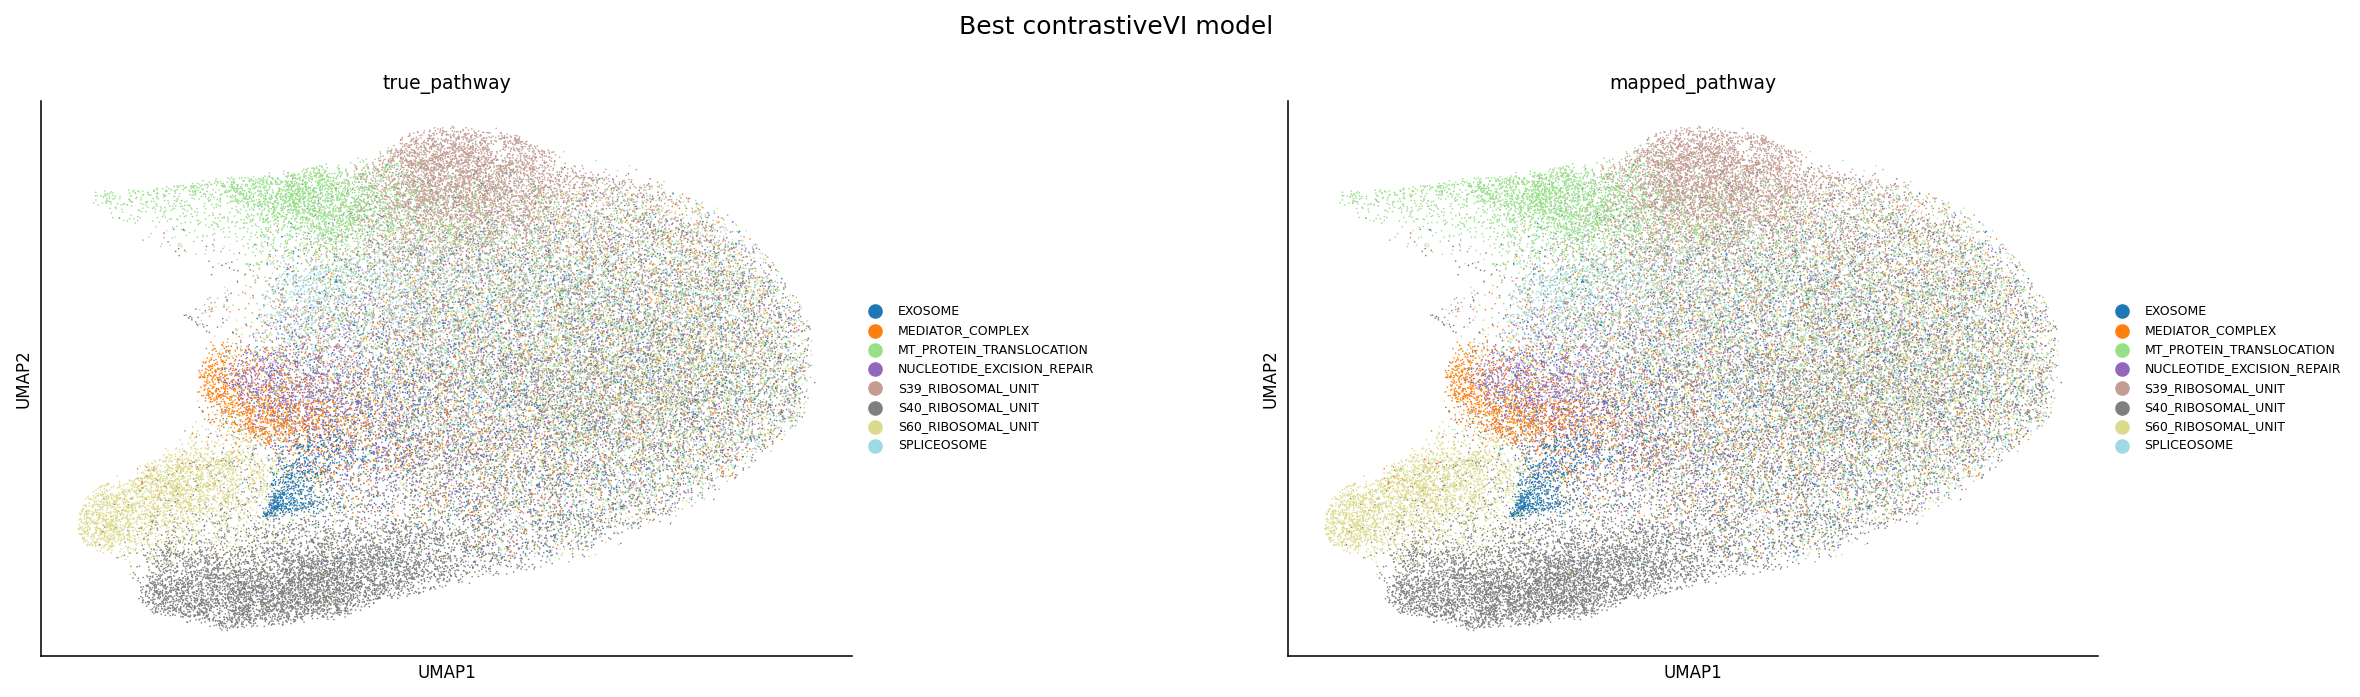


Generating figure for best scgen model


/var/tmp/ipykernel_3021632/4013088432.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/scgen_best_umap.svg


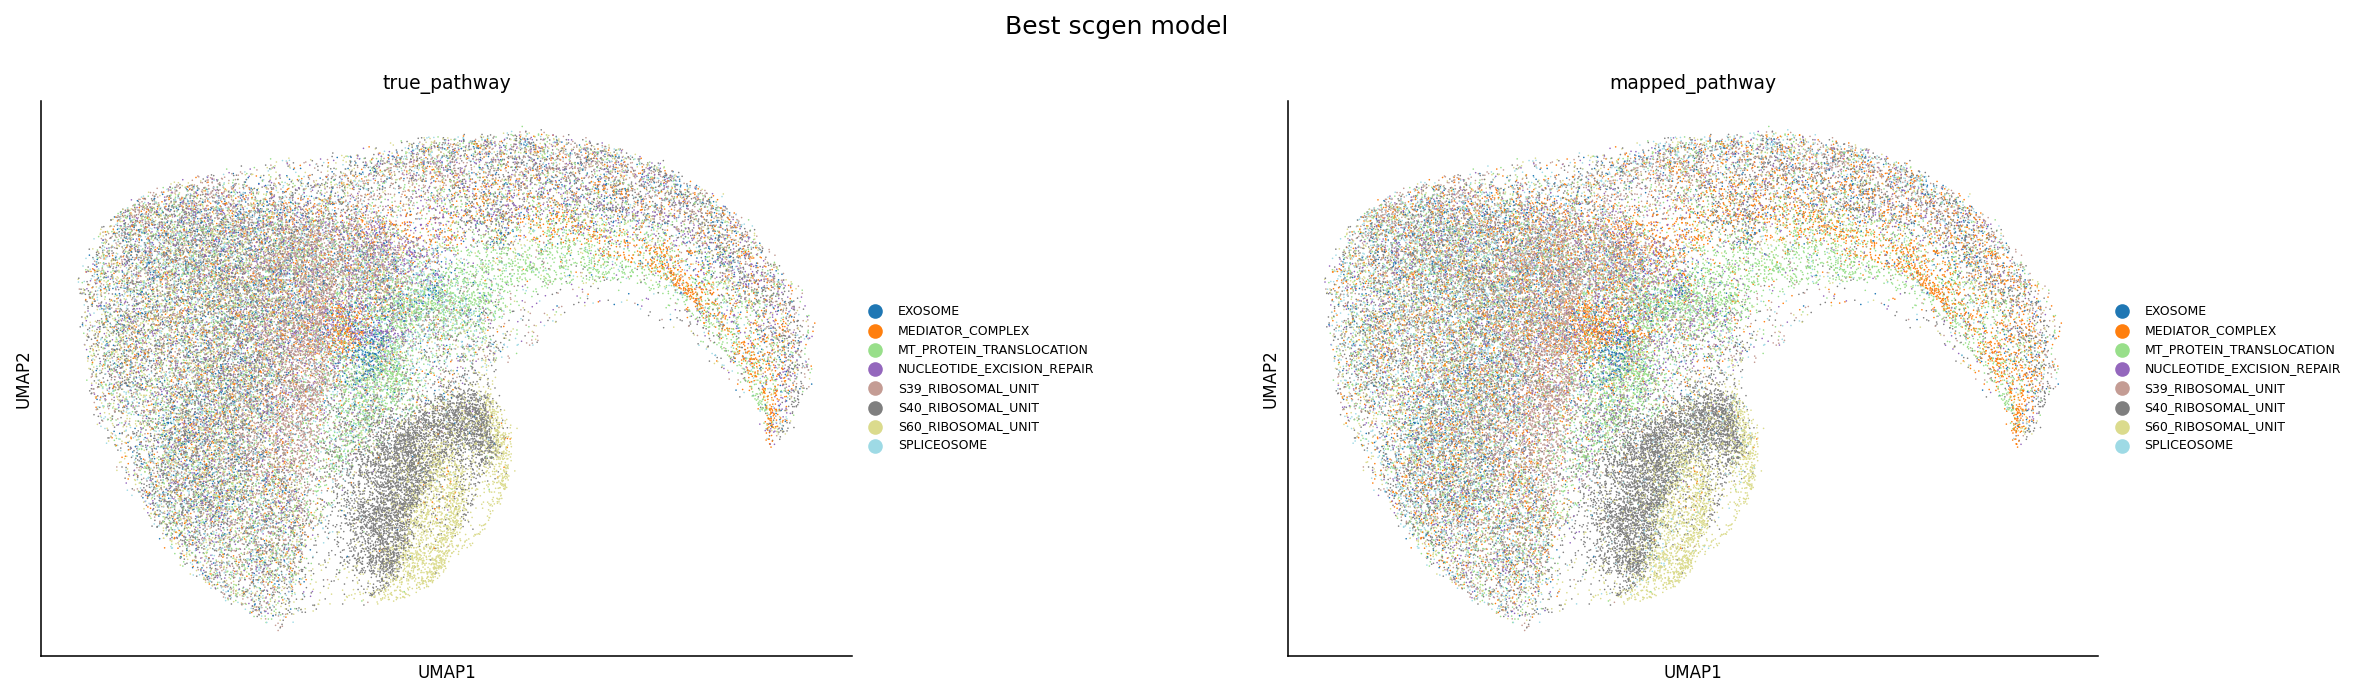

In [26]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

for method_name, model in best_run_model.items():
    print(f"\n{'='*60}\nGenerating figure for best {method_name} model\n{'='*60}")

    # Re-eval the best model for this method
    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)

    # UMAP on non-NTC cells
    sub = data[data.obs[p_key] != NTC].copy()
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)

    # Cluster z_corr on pathway genes
    z_corr  = np.asarray(data.uns['results']['z_corr'])
    z_perts = np.asarray(data.uns['results']['z_perts'])

    pert_to_idx = {name: i for i, name in enumerate(z_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = z_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    groups = slk.tl.cluster_rho(data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False)

    # Hungarian alignment of cluster → pathway labels
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': groups})
    pw_df = pathway_df_indexed.loc[pathway_df_indexed.index.isin(valid_genes)].reset_index()
    if 'gene' not in pw_df.columns:
        pw_df = pw_df.rename(columns={pathway_df_indexed.index.name or 'index': 'gene'})

    df_align  = pd.merge(clusters_df, pw_df, on='gene', how='inner')
    y_true    = df_align['pathway'].astype(str).values
    y_pred    = df_align['cluster'].astype(str).values
    true_lbl  = np.unique(y_true)
    pred_lbl  = np.unique(y_pred)

    C_mat = (
        pd.crosstab(df_align['pathway'].astype(str), df_align['cluster'].astype(str))
        .reindex(index=true_lbl, columns=pred_lbl, fill_value=0)
    )
    row_ind, col_ind = linear_sum_assignment(C_mat.values.max() - C_mat.values)
    mapping = {pred_lbl[j]: true_lbl[i] for i, j in zip(row_ind, col_ind)}
    df_align['mapped_pathway'] = [mapping.get(str(cl)) for cl in y_pred]

    # Subset z_sub to clustered genes and attach pathway labels
    clustered_genes = df_align['gene'].unique()
    z_sub = sub[sub.obs[p_key].isin(clustered_genes)].copy()

    gene_to_true   = dict(zip(df_align['gene'], df_align['pathway']))
    gene_to_mapped = dict(zip(df_align['gene'], df_align['mapped_pathway']))
    z_sub.obs['true_pathway']   = z_sub.obs[p_key].map(gene_to_true)
    z_sub.obs['mapped_pathway'] = z_sub.obs[p_key].map(gene_to_mapped)
    z_sub = z_sub[z_sub.obs['mapped_pathway'].notna()].copy()

    # Shared categorical palette across both columns
    all_cats  = pd.Index(np.unique(
        list(z_sub.obs['true_pathway'].dropna().unique()) +
        list(z_sub.obs['mapped_pathway'].dropna().unique())
    ).astype(str))
    cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
    z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
    z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

    cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))
    shared_palette = {cat: to_hex(cmap_col(i)) for i, cat in enumerate(all_cats)}
    z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in z_sub.obs['true_pathway'].cat.categories]
    z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in z_sub.obs['mapped_pathway'].cat.categories]

    # Plot and save
    fig = sc.pl.umap(
        z_sub,
        color=['true_pathway', 'mapped_pathway'],
        wspace=0.4,
        show=False,
        return_fig=True,
    )
    fig.suptitle(f'Best {method_name} model', y=1.02, fontsize=12)
    save_path = f'{RESULTS_DIR}/figures/{method_name}_best_umap.svg'
    fig.savefig(save_path, bbox_inches='tight')
    print(f"  Saved → {save_path}")
    plt.show()